In [30]:
# LOADING LIBRARIES

import numpy as np # numerical values
import pandas as pd # tables
import matplotlib.pyplot as plt # for plots
import joblib # set of tools for lightweight pipelining
import time
import os

from matplotlib.patches import FancyBboxPatch 
from sklearn.model_selection import train_test_split # splits the data into train and test sets
from sklearn.model_selection import RandomizedSearchCV # finds the best settings for the ML algorithm
from sklearn.model_selection import cross_val_score # evaluates the model's performance with a cross-validation
from sklearn.preprocessing import StandardScaler # puts numerical features on the same scale to prevent larger values dominating
from sklearn.linear_model import LogisticRegression # creates a logistic regression model for classification
from sklearn.ensemble import RandomForestClassifier # imports a random forest classifier - enables multiple decision trees
from sklearn.ensemble import HistGradientBoostingClassifier # gradient boosting model for classification
from sklearn.neural_network import MLPClassifier # multi layer perceptron, which is a neural network classifier
from sklearn.pipeline import make_pipeline # creates a machine learning pipeline
from sklearn.metrics import f1_score # calculates the f1 score to evaulate the model's performance
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from xgboost import XGBClassifier # XGBoost gradient boosting - based on preliminary proposal - additional model

pd.set_option("display.width", 120)
print("All libraries loaded :) ")

All libraries loaded :) 


## Data Preparation

In [31]:
Clean_data = pd.read_csv("~/Desktop/CARISURG/notebook-project/data/triage_cleaned_v1.csv")
Raw_data = pd.read_csv("~/Desktop/CARISURG/notebook-project/data/yaleemmlc_admissionprediction_triage.csv")


print("Raw Data:", Raw_data.shape[0], "rows and", Raw_data.shape[1], "columns")
print("Cleaned Data:", Clean_data.shape[0], "rows and", Clean_data.shape[1], "columns")

Raw_data.head()
Clean_data.head()

Raw Data: 55121 rows and 226 columns
Cleaned Data: 55121 rows and 225 columns


,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,A,4,87,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,...,0,0,0,0,0,0,0,0,0,0
1,B,2,53,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,...,0,0,0,0,0,0,0,0,0,0
2,A,2,49,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,...,0,0,1,0,0,0,0,0,0,0
3,A,3,22,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,...,0,0,0,0,0,0,0,0,0,0
4,A,2,62,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,...,0,0,0,0,0,0,0,0,0,0


In [32]:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp"]

df = Raw_data.copy() # creates a copy of the raw dataset

# Remove unwanted columns
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")], errors="ignore")

# covert vital signs to numeric values. Invalid text becomes missing (NaN)
for col in VITALS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# clean the esi target and keep the valid triage levels of 1-5
df["esi"] = pd.to_numeric(df["esi"], errors="coerce")
df = df[df["esi"].isin([1, 2, 3, 4, 5])].copy()

# removing any impossible vital values
# temperature outside human range
df.loc[(df["triage_vital_temp"] < 90) | (df["triage_vital_temp"] > 110), "triage_vital_temp"] = np.nan

# oxygen saturation - impossible to reach over 100%
df.loc[df["triage_vital_o2"] > 100, "triage_vital_o2"] = np.nan

# encoding the genders: Male = 0, Female = 1

df["gender"] = (df["gender"].astype(str).str.strip().str.lower().map({"male": 0, "m": 0, "female": 1, "f": 1}))

# filling the missing values with median values
for col in VITALS + ["age", "gender"]:
    df[col] = df[col].fillna(df[col].median())

# Making sure the ESI is an integer
df["esi"] = df["esi"].astype(int)

print("Modelling table ready:", df.shape)
df["esi"].value_counts().sort_index()

df.to_csv("~/Desktop/CARISURG/notebook-project/data/modelling_table.csv", index=False)

print("Modelling table saved successfully.")

Modelling table ready: (55121, 225)
Modelling table saved successfully.


## Feature and Target Selection

The target varigble was set as ESI Level (1-5), representing the emergency severity.

Features that could introduce data leakage were removed, including patient outcomes and administrative information. The remaining features focused on information available during initial triage.


In [33]:
# Choosing features and targets and rebuilding week 6 split.

TARGET = "esi"

# who the patients are
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion", "maritalstatus", "employstatus", "insurance_status"]

# administration information
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]

# Outcome of the visit 
LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]

X = df[FEATURES]
y = df[TARGET]

print("The models will use:", len(FEATURES), "features. A few examples:", FEATURES[:6])

The models will use: 208 features. A few examples: ['triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2', 'triage_vital_o2_device']


In [34]:
# Reproducing the same split from week 6

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("train:", X_train.shape[0], "and test:", X_test.shape[0])

train: 44096 and test: 11025


## Chief Complaint Exploration

The chief complaint features were used to understand their usefulness for predicting ESI.

The "cc_other" category was analysed to determine how frequently it occurred and whether it was associated with differences in average ESI levels.

In [35]:
# Exploring the chief complaint category

if "cc_other" in df.columns:
     chief_complaints = [col for col in df.columns if col.startswith("cc_")] #list of all the chief complaint columns
     total_patients = len(df) # total number of patients
     other_patients = int(df["cc_other"].sum()) # patients who have other is flagged as a chief complaint
     only_other_patients = int(((df["cc_other"] == 1) & (df[chief_complaints].sum(axis=1) == 1)).sum()) # counts patients whose only chief complaint is "other"
     
     # displaying statistics
     print(f"Patients flagged with 'cc_other': " f"{other_patients} of {total_patients}" f"({other_patients / total_patients:.1%})")
     print(f"Patients whose only recorded chief complaint is 'other': "f"{only_other_patients}")
     
     # Compare the average ESI score for patients with and without cc_other
     print("\nAverage ESI by cc_other flag:")
     print(df.groupby("cc_other")["esi"].mean().round(2))
else:
     print("No 'cc_other' column found. Analysis skipped.")

Patients flagged with 'cc_other': 4491 of 55121(8.1%)
Patients whose only recorded chief complaint is 'other': 3352

Average ESI by cc_other flag:
cc_other
0.0    2.87
1.0    3.01
2.0    3.26
3.0    3.00
Name: esi, dtype: float64


## Baseline Logistic Regression Model

Logistic Regression was trained as a baseline model because it provides a simple and interpretable comparison for more complex algorithms.

A pipeline with feature was used to ensure numerical features were on a similar scale.

Performance was measured using accuracy and Macro F1, with Macro F1 being important due to the imbalance between ESI classes.

Baseline Logistic Regression Performance
Accuracy score : 0.667
Macro F1 score : 0.492


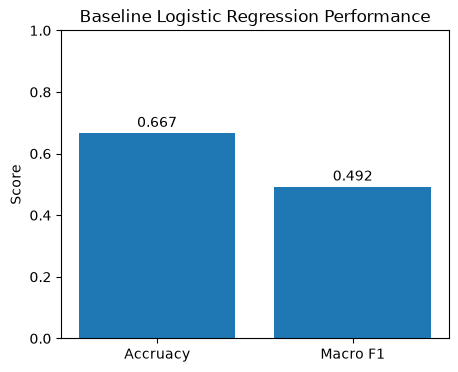

In [36]:
# Training the baseline Logistic Regression Model

# creating a pipeline
baseline_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42)
)

# Training the model
baseline_model.fit(X_train, y_train)

# Generating predictions
baseline_predictions = baseline_model.predict(X_test)

# Evaluating the model performance
baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_f1 = f1_score(y_test, baseline_predictions, average="macro")

print("Baseline Logistic Regression Performance")
print(f"Accuracy score : {baseline_accuracy:.3f}")
print(f"Macro F1 score : {baseline_f1:.3f}")

# Visualising the perfomance
metrics = ["Accruacy", "Macro F1"]
scores = [baseline_accuracy, baseline_f1]

plt.figure(figsize=(5,4))
plt.bar(metrics, scores)
plt.title("Baseline Logistic Regression Performance")
plt.ylabel("Score")
plt.ylim(0, 1)

# displaying the matric values for each bar
for i, score in enumerate(scores):
    plt.text(i, score + 0.02, f"{score:.3f}", ha="center")


os.makedirs("figs", exist_ok=True)
plt.savefig("figs/logistic_regression_baseline.png", dpi=120, bbox_inches="tight") # saves image into figs folder
plt.show()

Results:
Baseline Logistic Regression Performance
| Accuracy Score | Macro F1 Score |
| ---------------| ---------------|
| 0.667 | 0.492 |

The logistic regression model was able to achieve a 66.7% as it correctly identified most of the test cases. The Macro F1 score of 0.492 shows a reduced performance across ESI categories, highlighting the need to evalute more than accuracy alone. 

## Feature Engineering: Physiological Stress Score

Additional clinical features were created from vital signs to represent physiological instability.

By definition: Cardiovascular stress during triage can be assessed by analysing key physiological measurements including Blood Pressure, Heart Rate, Respiratory Rate, and Oxygen Saturation. These measurements were selected because they provide information about a patient's cardiovascular and respiratory stability. Combining them allows the model to identify patterns of physiological stress that may not be captured by a single vital sign alone.

Features included abnormal heart rate, oxygen saturation, respiratory rate, blood pressure, shock index, and pulse pressure.

These features were created because combinations of vital sign abnormalities may provide more useful information about patient severity than individual measurements alone.


In [37]:
# CREATING ADDITIONAL CLINICAL FEATURES : Physiological Stress Indicators

def add_clinical_features(data):

    # creating a copy 
    features = data.copy()

    # individual phsyiological warning indicators
    features["high_heart_rate"] = (features["triage_vital_hr"] > 100).astype(int) # a high heart rate indicates an increase in cardiovascular activity or an indication of underlying issues
    features["low_oxygen_sat"] = (features["triage_vital_o2"] < 92).astype(int) # reduced oxygen sat can indicate respiratory or cardiovascular compromise
    features["high_resp_rate"] = (features["triage_vital_rr"] > 20).astype(int) # increased respiratory rate may indicate physiological distress
    features["low_blood_pressure"] = (features["triage_vital_sbp"] < 90).astype(int) # low systolic blood pressure suggest reduced circulation

    # combining the indicators into a stress score
    stress_indicator = ["high_heart_rate", "low_oxygen_sat", "high_resp_rate", "low_blood_pressure"]

    features["physiological_stress_score"] = (features[stress_indicator].sum(axis=1))

    # shock index
    features["shock_index"] = (features["triage_vital_hr"] / (features["triage_vital_sbp"] + 1e-5))

    # pulse pressure
    features["pulse_pressure"] = (features["triage_vital_sbp"] - features["triage_vital_dbp"])

    # vital sign abnormalities
    features["temp_abnormal"] = ((features["triage_vital_temp"] < 96.8) | (features["triage_vital_temp"] > 100.4)).astype(int)
    features["hr_abnormal"] = ((features["triage_vital_hr"] < 60) | (features["triage_vital_hr"] > 100)).astype(int)
    features["rr_abnormal"] = ((features["triage_vital_rr"] < 12) | (features["triage_vital_rr"] > 20)).astype(int)
    features["o2_abnormal"] = (features["triage_vital_o2"] < 95).astype(int)

    # cleaning up values
    features.replace([np.inf, -np.inf], np.nan, inplace=True)

    for col in [
        "shock_index",
        "pulse_pressure"
    ]:
        features[col] = (
            features[col]
            .fillna(features[col].median())
        )

    return features

# applying the added features to the training and testind data
X_train_fe = add_clinical_features(X_train)
X_test_fe = add_clinical_features(X_test)
X_train_fe.head()

# Display
print("Features before engineering:", X_train.shape[1])
print("Features after engineering:", X_train_fe.shape[1])


# checking how often the new stress score identifies warning signs
print( X_train_fe["physiological_stress_score"].value_counts().sort_index())

Features before engineering: 208
Features after engineering: 219
physiological_stress_score
0    33915
1     8963
2     1095
3      119
4        4
Name: count, dtype: int64


Physiological Stress Score Results and Explanation 

| Physiological Stress Score | Number of Patients |
|---------------------------|--------------------|
| 0                         |       33915       |
| 1                         |        8963      |
| 2                         |       1095          |
| 3                         |        119         |
| 4                         |         4       |

This indicates that most patients had no abnormal indicators while a smaller section of patients demonstrated multiple abnormalities. This distribution reflects the rarity of patients presenting with several severe physiological disturbances.

## Random Forest Model Training

A Random Forest model was trained using the engineered features.

Random Forest was selected because it can capture complex relationships between clinical variables. Class weighting was applied to help address the imbalance between ESI categories.

Feature importance was also analysed to identify which variables contributed most to model predictions.


Rarest chief-complaint flags (lowest positive counts in training set):
cc_cardiacarrest           0.0
cc_fulltrauma              4.0
cc_exposuretostd           7.0
cc_bodyfluidexposure       9.0
cc_ingestion              10.0
cc_foreignbodyineye       10.0
cc_modifiedtrauma         11.0
cc_conjunctivitis         12.0
cc_trauma                 12.0
cc_hyperglycemia          13.0
cc_tickremoval            13.0
cc_thumbinjury            16.0
cc_seizures               17.0
cc_respiratorydistress    17.0
cc_rectalbleeding         17.0
cc_overdose-accidental    17.0
cc_earproblem             18.0
cc_motorcyclecrash        21.0
cc_cellulitis             21.0
cc_eyeinjury              22.0
dtype: float64
Random Forest Performance
Macro F1 Score: 0.392

Top 15 Features Used by Random Forest:
shock_index                   0.075747
triage_vital_dbp              0.074773
triage_vital_sbp              0.074515
triage_glucose                0.071294
pulse_pressure                0.068963
triage_vit

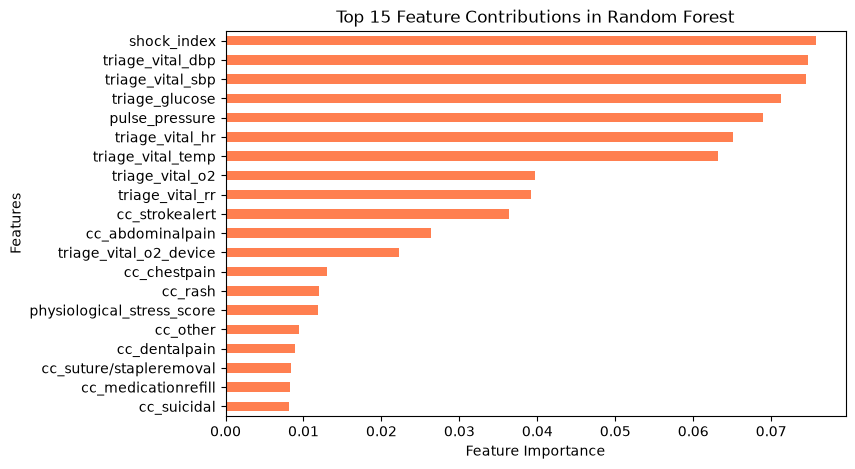

In [38]:
# Random Forest Model Training

cc_cols =[c for c in X_test_fe.columns if c.startswith("cc_")]
rare_cc_counts = X_train_fe[cc_cols].sum().sort_values()
print("\nRarest chief-complaint flags (lowest positive counts in training set):")
print(rare_cc_counts.head(20))

rf_model = RandomForestClassifier(
    n_estimators=300, # number of trees in the forest
    class_weight="balanced_subsample", # adjusts for the ESI imbalance
    random_state=42, 
    n_jobs=-1 ) # n_jobs accepts integer values, -1 means all avaliable cores should be used.

# traning the model using the new features
rf_model.fit(X_train_fe, y_train)
rf_predictions = rf_model.predict(X_test_fe) # generates predictions on the test dataset

rf_macro_f1 = f1_score( # Macro F1 gives equal importance to each ESI category, making it suitable for an imbalanced triage dataset
    y_test,
    rf_predictions,
    average="macro")

# Display
print("Random Forest Performance")
print(f"Macro F1 Score: {rf_macro_f1:.3f}")

# FEATURE IMPROTANCE ANALYSIS

# Extracts how much each feature contributed to the model's decisions
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train_fe.columns
)

# Sort features from most to least important
top_features = (
    feature_importance
    .sort_values(ascending=False)
    .head(20)
)

print("\nTop 15 Features Used by Random Forest:")
print(top_features)

# Visualising the feature importance
plt.figure(figsize=(8,5))

top_features.sort_values().plot(
    kind="barh",
    color="coral"
)

plt.title("Top 15 Feature Contributions in Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.savefig("figs/random_forest_top_features.png", dpi=120, bbox_inches="tight") # saves image into figs folder
plt.show()



## Random Forest Hyperparameter Tuning

RandomizedSearchCV was used to test different Random Forest settings and identify the best-performing combination.

Macro F1 was selected as the optimisation metric because it evaluates performance across all ESI categories equally.

In [39]:
# RANDOM FOREST HYPERPARAMETER TUNING

param_dist = {
    "n_estimators": [300, 400, 500], # the number of trees
    "max_depth": [10, 14, 20, None], # maximum tree depth
    "min_samples_leaf": [1, 2, 4, 8], #minimum samples per leaf
    "min_samples_split": [2, 5, 10, 20],
    "max_features": ["sqrt", "log2"] # number of features considered per split
}

# creating the random forest for testing
rf_tuning = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    estimator=rf_tuning, # random forest model being tuned
    param_distributions=param_dist, # range of hyperparameter values that the RandomizedSearchCV will explore
    n_iter=25, # test 8 random combinations
    cv=5, # a 3 fold cross evalutation to test the model's performance
    scoring="f1_macro", #  uses the macro-f1 value as an evaluation metric to give equal importance to each ESI classes
    random_state=42, # random search produces the same results each time
    n_jobs=-1 
)

search.fit(X_train_fe, y_train)

# Display
print("The Best Parameters:")
print(search.best_params_)

# displays the cross validation score
print("\nBest Cross-Validation Macro F1:")
print(round(search.best_score_, 3))

# evaluate the model on the unseen test data
best_rf = search.best_estimator_

best_rf.fit(X_train_fe, y_train)

rf_tuned_predictions = best_rf.predict(X_test_fe)

rf_tuned_f1 = f1_score(
    y_test,
    rf_tuned_predictions,
    average="macro"
)

print("\nTest Macro F1 Score:")
print(round(rf_tuned_f1, 3))

print("\nPer-class performance on test set (tuned Random Forest):")
print(classification_report(y_test, rf_tuned_predictions, digits=3))

# COMPARING BASELINE AND RANDOM FOREST

rf_results = pd.DataFrame({
    "Model": [
        "Random Forest (Baseline)",
        "Random Forest (Tuned)"
    ],
    "Macro F1 Score": [
        rf_macro_f1,
        rf_tuned_f1
    ]
})

rf_train_predictions = best_rf.predict(X_train_fe)

print(
    "Training Macro F1:",
    round(
        f1_score(
            y_train,
            rf_train_predictions,
            average="macro"
        ),
        3
    )
)

rf_results

The Best Parameters:
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}

Best Cross-Validation Macro F1:
0.427

Test Macro F1 Score:
0.425

Per-class performance on test set (tuned Random Forest):
              precision    recall  f1-score   support

           1      0.217     0.312     0.256        16
           2      0.626     0.683     0.653      3585
           3      0.783     0.368     0.501      5402
           4      0.358     0.738     0.482      1779
           5      0.148     0.539     0.232       243

    accuracy                          0.534     11025
   macro avg      0.427     0.528     0.425     11025
weighted avg      0.649     0.534     0.541     11025

Training Macro F1: 0.599


,Model,Macro F1 Score
0,Random Forest (Baseline),0.392325
1,Random Forest (Tuned),0.425021


## Model Benchmarking

A benchmarking table was created to compare models using performance, efficiency, and explainability.

Metrics included:
- Accuracy
- ESI-1 Recall
- Macro F1 score
- Training time
- Prediction time

ESI-1 recall was included because identifying the highest-risk patients is a key requirement for emergency triage support.

In [40]:
from sklearn.metrics import recall_score
from sklearn.base import clone
import time

# comparing model performance
def benchmark_model(model, X_train, y_train, X_test, y_test, model_name):
    
    model = clone(model) # making a copy of the model

    # measuring the training time
    starttime = time.perf_counter ()
    model.fit(X_train, y_train)
    traintime = time.perf_counter () - starttime

    # measuring the prediction time
    starttime = time.perf_counter()
    predictions = model.predict(X_test)
    predictiontime = time.perf_counter() - starttime 

    # calculating the prediction per patients
    time_per_patient = (predictiontime / len(X_test)) * 1000

    # store the results
    results = {
        "Model": model_name,
        "Accuracy": round(accuracy_score(y_test, predictions), 3),
        "ESI-1 Recall": round(recall_score(y_test, predictions, labels=[1], average=None)[0], 3),
        "Macro F1": round(f1_score(y_test, predictions, average="macro"), 3),
        "Training Time (s)": round(traintime, 2),
        "Prediction Time (ms/patient)": round(time_per_patient, 4)
    }

    return results

# Explainability was rated based on how easy it is to understand why a model made a prediction
# Logistic Regression: easier to explain because feature weights can be viewed
# Random Forest: harder to explain because it combines many decision trees

explainability = {
    "Logistic Regression (Baseline)": "High",
    "Random Forest (Baseline)": "Medium",
    "Random Forest (Tuned)": "Medium"
}


# run the benchmark tests for each model
benchmark_results = [
    benchmark_model(
        baseline_model, 
        X_train, 
        y_train, 
        X_test, 
        y_test, 
        "Logistic Regression (Baseline)"
    ),

    benchmark_model(
        rf_model, 
        X_train_fe, 
        y_train, 
        X_test_fe, 
        y_test, 
        "Random Forest (Baseline)"
    ),

    benchmark_model(
        best_rf, 
        X_train_fe, 
        y_train, 
        X_test_fe, 
        y_test, 
        "Random Forest (Tuned)"
    )
]


# table showing model comparison
benchmark_table = pd.DataFrame(benchmark_results)

# Add explainability scores
benchmark_table["Explainability"] = benchmark_table["Model"].map(explainability)

# Display results
benchmark_table

benchmark_table.to_csv("benchmark_table_week7.csv", index=False)
print("Saved:", os.path.abspath("Week7_Benchmark.csv"))

# Save results as a CSV file 
benchmark_table.to_csv("Week7_Benchmark.csv", index=False)

print("Week 7 Random Forest Benchmark Table Saved Successfully")


Saved: /Users/zmcdee/Desktop/CARISURG/notebook-project/Week7/Week7_Benchmark.csv
Week 7 Random Forest Benchmark Table Saved Successfully


## Benchmark Results Discussion

The benchmark comparison showed that Logistic Regression achieved the best overall performance, with the highest accuracy (0.667) and Macro F1 score (0.492). It was also the fastest model and had the highest explainability, making it a strong baseline model.

The baseline Random Forest achieved similar accuracy but had a lower Macro F1 score and failed to identify any ESI-1 patients (recall = 0.0). After tuning, Random Forest improved ESI-1 recall to 0.312, showing better detection of high-priority patients, although overall performance decreased.

These results demonstrate the trade-off between general model performance and identifying critical cases. For emergency triage, improving ESI-1 detection remains an important area for future model development.

In [41]:
# Diagnostic Testing for logistic regression on the same feature set as the RF
# this is to see whether the lower RF score is due to the model or the added features

logreg_fe_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42)
)

logreg_fe_model.fit(X_train_fe, y_train)
logreg_fe_predictions = logreg_fe_model.predict(X_test_fe)
logreg_fe_f1 = f1_score(y_test, logreg_fe_predictions, average="macro")


print("Logistic Regression on engineered features (X_train_fe) -- Macro F1:", round(logreg_fe_f1, 3))
print("Logistic Regression on original features (X_train)      -- Macro F1:", round(baseline_f1, 3))
print("Random Forest (Tuned) on engineered features             -- Macro F1:", round(rf_tuned_f1, 3))

Logistic Regression on engineered features (X_train_fe) -- Macro F1: 0.493
Logistic Regression on original features (X_train)      -- Macro F1: 0.492
Random Forest (Tuned) on engineered features             -- Macro F1: 0.425


To check whether the new engineered features were affecting the Random Forest (RF) performance, Logistic Regression (LG) was tested using both original features and the engineered features. The macro f1 scores were almost identical (0.492 vs 0.493), indicating that the engineered features were not responsible for the Random Forest's lower performance. With independent chief complaints, LG is better at combining the small pieces of information while RF is less effective as it considers a subset of features at each decision split.

# Baseline XGBoost Model - What the cell below does

This trains a baseline XGBoost classifier using the engineered feature set. Since the ESI classes are imbalanced, balanced sample weights are applied during the training to give importance to underrepresented classes. The model then evaluates on the test set using a Macro F1 score and a classification report is used to interpret the overall performance

In [42]:
# XGBOOST BASELINE MODEL

from sklearn.utils.class_weight import compute_sample_weight # calculates sample weights for imbalanced classes

# class labels need to start from 0 instead of 1
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train_xgb) # creates a balanced sample weight

xgb_baseline = XGBClassifier(
    n_estimators=300, # matches with RF baseline for fair comparison
    objective="multi:softprob", # multi class classification
    num_class=5, # predicts the 5 esi levels
    eval_metric="mlogloss", # evaluation metric used during training
    random_state=42,
    n_jobs=-1
)

# training the model with the balanced weights
xgb_baseline.fit(X_train_fe, y_train_xgb, sample_weight=sample_weights)
xgb_predictions = xgb_baseline.predict(X_test_fe) + 1 # this shifts it back to ESI Level 1 to 5
xgb_macro_f1 = f1_score(y_test, xgb_predictions, average="macro")

# display
print("XGBoost (Baseline) Performance")
print(f"Macro F1 Score: {xgb_macro_f1:.3f}")
print("\nPer-Class Performance on Test Set (XGBoost Baseline):")
print(classification_report(y_test, xgb_predictions, digits=3))

# training Macro F1 for the baseline
xgb_baseline_train_predictions = xgb_baseline.predict(X_train_fe) + 1
xgb_baseline_train_f1 = f1_score(y_train, xgb_baseline_train_predictions, average="macro")
print("\nTraining Macro F1:", round(xgb_baseline_train_f1, 3))

XGBoost (Baseline) Performance
Macro F1 Score: 0.493

Per-Class Performance on Test Set (XGBoost Baseline):
              precision    recall  f1-score   support

           1      0.400     0.250     0.308        16
           2      0.671     0.707     0.689      3585
           3      0.740     0.551     0.632      5402
           4      0.495     0.703     0.581      1779
           5      0.173     0.490     0.256       243

    accuracy                          0.625     11025
   macro avg      0.496     0.540     0.493     11025
weighted avg      0.665     0.625     0.633     11025


Training Macro F1: 0.738


## Hyperparameter Tuning (XGBoost)

In [43]:
# Hyperparameter
param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3]
}

# XGBoost model used for tuning
xgb_tuning = XGBClassifier(
    objective="multi:softprob",
    num_class=5,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

# Randomised search
search_xgb = RandomizedSearchCV(
    estimator=xgb_tuning,
    param_distributions=param_dist,
    n_iter=25,        # tests 25 random combinations
    cv=5,             # 5-fold cross validation
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1
)

# Train each parameter combination using balanced weights
search_xgb.fit(
    X_train_fe,
    y_train_xgb,
    sample_weight=sample_weights
)


print("Best XGBoost Parameters:")
print(search_xgb.best_params_)


print("\nBest Cross Validation Macro F1:")
print(round(search_xgb.best_score_,3))

best_xgb = search_xgb.best_estimator_

xgb_tuned_predictions = best_xgb.predict(X_test_fe) + 1

xgb_tuned_f1 = f1_score(
    y_test,
    xgb_tuned_predictions,
    average="macro"
)

print("Tuned XGBoost Performance")
print(f"Macro F1 Score: {xgb_tuned_f1:.3f}")

print("\nPer-Class Performance:")
print(classification_report(y_test, xgb_tuned_predictions, digits=3))

xgb_tuned_train_predictions = best_xgb.predict(X_train_fe) + 1

xgb_tuned_train_f1 = f1_score(
    y_train,
    xgb_tuned_train_predictions,
    average="macro"
)

print("\nTraining Macro F1:", round(xgb_tuned_train_f1, 3))

Best XGBoost Parameters:
{'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}

Best Cross Validation Macro F1:
0.572
Tuned XGBoost Performance
Macro F1 Score: 0.435

Per-Class Performance:
              precision    recall  f1-score   support

           1      0.076     0.312     0.122        16
           2      0.670     0.685     0.677      3585
           3      0.763     0.490     0.597      5402
           4      0.445     0.689     0.541      1779
           5      0.145     0.638     0.237       243

    accuracy                          0.589     11025
   macro avg      0.420     0.563     0.435     11025
weighted avg      0.667     0.589     0.605     11025


Training Macro F1: 0.492


## Neural Network - Small Multilayer Perceptron (MLP)

Trains a small MLP neural network using standardised features and evaluates the macro f1 score

In [44]:
# NEURAL NETWORK
mlp = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=(64, 32),
        alpha=1e-3,
        max_iter=500,
        random_state=42
    )
)

mlp.fit(X_train_fe, y_train)
mlp_predictions = mlp.predict(X_test_fe)

mlp_f1 = f1_score(y_test, mlp_predictions, average="macro")

print("Small MLP Performance")
print(f"Macro F1 Score: {mlp_f1:.3f}")
print("\nPer-Class Performance:")
print(classification_report(y_test, mlp_predictions, digits=3))

mlp_train_predictions = mlp.predict(X_train_fe)

mlp_train_f1 = f1_score(
    y_train,
    mlp_train_predictions,
    average="macro"
)

print("MLP Training F1:", round(mlp_train_f1,3))


Small MLP Performance
Macro F1 Score: 0.457

Per-Class Performance:
              precision    recall  f1-score   support

           1      0.250     0.188     0.214        16
           2      0.640     0.639     0.639      3585
           3      0.651     0.672     0.661      5402
           4      0.550     0.526     0.538      1779
           5      0.304     0.185     0.230       243

    accuracy                          0.626     11025
   macro avg      0.479     0.442     0.457     11025
weighted avg      0.623     0.626     0.624     11025

MLP Training F1: 0.725


## HistGradientBoosting Baseline

In [45]:
# HISGRADIENTBOOSTING 
# training on engineered features

hgb = HistGradientBoostingClassifier(
    max_depth=6,                # controls the tree complexity
    learning_rate=0.1,  # contribution to each boosting step
    max_iter=300, # number of boosting iterations
    class_weight="balanced",
    random_state=42
)

# train the model
hgb.fit(X_train_fe, y_train)

# test predictions
hgb_predictions = hgb.predict(X_test_fe)

# f1 score
hgb_f1 = f1_score(y_test, hgb_predictions, average="macro")

# display
print("HisGradientBoosting Performance")
print(f"Macro F1 Score: {hgb_f1:.3f}")
print("\nPer-Class Performance:")
print(classification_report(y_test, hgb_predictions, digits=3))

HisGradientBoosting Performance
Macro F1 Score: 0.404

Per-Class Performance:
              precision    recall  f1-score   support

           1      0.091     0.312     0.141        16
           2      0.650     0.643     0.646      3585
           3      0.781     0.398     0.527      5402
           4      0.360     0.732     0.483      1779
           5      0.138     0.601     0.225       243

    accuracy                          0.536     11025
   macro avg      0.404     0.537     0.404     11025
weighted avg      0.655     0.536     0.552     11025



## Histogradientboosting Hyperparameter Tuning

In [46]:
# Hyperparameter search space
param_dist_hgb = {
    "learning_rate": [0.01, 0.05, 0.1],
    "max_iter": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, None],
    "min_samples_leaf": [10, 20, 30, 50],
    "l2_regularization": [0, 0.1, 0.5, 1.0]
}


# Model used during tuning
hgb_tuning = HistGradientBoostingClassifier(
    class_weight="balanced",
    random_state=42
)

# Randomised hyperparameter search
search_hgb = RandomizedSearchCV(
    estimator=hgb_tuning,
    param_distributions=param_dist_hgb,
    n_iter=25,        # tests 25 random combinations
    cv=5,             # 5-fold cross validation
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1

)

search_hgb.fit(
    X_train_fe,
    y_train
)


print("Best HistGradientBoosting Parameters:")
print(search_hgb.best_params_)
print("\nBest Cross Validation Macro F1:")
print(round(search_hgb.best_score_,3))

best_hgb = search_hgb.best_estimator_

# test predictions
hgb_tuned_predictions = best_hgb.predict(X_test_fe)

# calculate test Macro F1
hgb_tuned_f1 = f1_score(
    y_test,
    hgb_tuned_predictions,
    average="macro"
)

print("Tuned HistGradientBoosting Performance")
print(f"Macro F1 Score: {hgb_tuned_f1:.3f}")

print("\nPer-Class Performance:")
print(classification_report(y_test, hgb_tuned_predictions, digits=3))

# training performance for overfitting check
hgb_tuned_train_predictions = best_hgb.predict(X_train_fe)

hgb_tuned_train_f1 = f1_score(
    y_train,
    hgb_tuned_train_predictions,
    average="macro"
)

print("\nTraining Macro F1:", round(hgb_tuned_train_f1, 3))

Best HistGradientBoosting Parameters:
{'min_samples_leaf': 10, 'max_iter': 300, 'max_depth': None, 'learning_rate': 0.1, 'l2_regularization': 0.5}

Best Cross Validation Macro F1:
0.444
Tuned HistGradientBoosting Performance
Macro F1 Score: 0.436

Per-Class Performance:
              precision    recall  f1-score   support

           1      0.098     0.312     0.149        16
           2      0.651     0.686     0.668      3585
           3      0.761     0.481     0.589      5402
           4      0.453     0.672     0.541      1779
           5      0.139     0.658     0.230       243

    accuracy                          0.582     11025
   macro avg      0.420     0.562     0.436     11025
weighted avg      0.661     0.582     0.598     11025


Training Macro F1: 0.497


## Six-Axis Model Benchmark

A six-axis benchmark was created to compare the performance of each machine learning model.

The models were evaluated using:

- **Accuracy:** Overall prediction performance.
- **ESI-1 Recall:** Ability to identify the highest-risk patients.
- **Macro F1 Score:** Main evaluation metric due to ESI class imbalance.
- **Training Time:** Time required to train each model.
- **Prediction Time:** Speed of generating predictions for new patients.
- **Explainability:** How easily model decisions can be interpreted.

This benchmark compares both baseline and tuned models to evaluate the trade-off between predictive performance, efficiency and clinical usability.

In [47]:
from sklearn.base import clone
from sklearn.metrics import recall_score
import time

def benchmark_model(model, X_train, y_train, X_test, y_test, model_name):
    
    model = clone(model)

    # training time
    start = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - start

    # prediction time
    start = time.perf_counter()
    predictions = model.predict(X_test)
    prediction_time = time.perf_counter() - start

    # milliseconds per patient
    ms_patient = (prediction_time / len(X_test)) * 1000

    return {
        "Model": model_name,
        "Accuracy": round(accuracy_score(y_test, predictions), 3),
        "ESI-1 Recall": round(
            recall_score(
                y_test,
                predictions,
                labels=[1],
                average=None
            )[0],
            3
        ),
        "Macro F1": round(
            f1_score(
                y_test,
                predictions,
                average="macro"
            ),
            3
        ),
        "Training Time (s)": round(train_time, 2),
        "Prediction Time (ms/patient)": round(ms_patient, 4)
    }


# Explainability ratings
explainability = {
    "Logistic Regression (Baseline)": "High",
    "Random Forest (Baseline)": "Medium",
    "Random Forest (Tuned)": "Medium",
    "XGBoost (Baseline)": "Medium",
    "XGBoost (Tuned)": "Medium",
    "HistGradientBoosting (Baseline)": "Medium",
    "HistGradientBoosting (Tuned)": "Medium",
    "MLP": "Low"
}


benchmark_results = [

    benchmark_model(
        baseline_model,
        X_train,
        y_train,
        X_test,
        y_test,
        "Logistic Regression (Baseline)"
    ),

    benchmark_model(
        rf_model,
        X_train_fe,
        y_train,
        X_test_fe,
        y_test,
        "Random Forest (Baseline)"
    ),

    benchmark_model(
        best_rf,
        X_train_fe,
        y_train,
        X_test_fe,
        y_test,
        "Random Forest (Tuned)"
    ),

    benchmark_model(
        xgb_baseline,
        X_train_fe,
        y_train_xgb,
        X_test_fe,
        y_test_xgb,
        "XGBoost (Baseline)"
    ),

    benchmark_model(
        best_xgb,
        X_train_fe,
        y_train_xgb,
        X_test_fe,
        y_test_xgb,
        "XGBoost (Tuned)"
    ),

    benchmark_model(
        hgb,
        X_train_fe,
        y_train,
        X_test_fe,
        y_test,
        "HistGradientBoosting (Baseline)"
    ),

    benchmark_model(
        best_hgb,
        X_train_fe,
        y_train,
        X_test_fe,
        y_test,
        "HistGradientBoosting (Tuned)"
    ),

    benchmark_model(
        mlp,
        X_train_fe,
        y_train,
        X_test_fe,
        y_test,
        "MLP"
    )
]


# create benchmark table
benchmark_table = pd.DataFrame(benchmark_results)

benchmark_table["Explainability"] = (
    benchmark_table["Model"]
    .map(explainability)
)

benchmark_table = benchmark_table.sort_values(
    by="Macro F1",
    ascending=False
)

benchmark_table

benchmark_table.to_csv(
    "Week7_Six_Axis_Benchmark.csv",
    index=False
)
print("Six-axis benchmark saved successfully.")
print(os.path.abspath("Week7_Six_Axis_Benchmark.csv"))

Six-axis benchmark saved successfully.
/Users/zmcdee/Desktop/CARISURG/notebook-project/Week7/Week7_Six_Axis_Benchmark.csv


## Model Evaluation - Overfitting Evaluation

Evaluating which model generates best to unseen patients, training and testing macro f1 scores were compared.

A high difference between training and testing performance would indicate a possible overfitting as the model learns specific patterns from the traning data but performs poorly on new cases.

In [48]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES:
# Compares training and testing Macro F1 scores to identify overfitting.
# ------------------------------------------------------------------

overfitting_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest Baseline",
        "Random Forest Tuned",
        "XGBoost Baseline",
        "XGBoost Tuned",
        "HistGradientBoosting Baseline",
        "HistGradientBoosting Tuned",
        "MLP"
    ],
    "Training Macro F1": [
        f1_score(y_train, baseline_model.predict(X_train), average="macro"),
        f1_score(y_train, rf_model.predict(X_train_fe), average="macro"),
        f1_score(y_train, best_rf.predict(X_train_fe), average="macro"),
        xgb_baseline_train_f1,
        xgb_tuned_train_f1,
        f1_score(y_train, hgb.predict(X_train_fe), average="macro"),
        hgb_tuned_train_f1,
        mlp_train_f1
    ],
    "Testing Macro F1": [
        baseline_f1,
        rf_macro_f1,
        rf_tuned_f1,
        xgb_macro_f1,
        xgb_tuned_f1,
        hgb_f1,
        hgb_tuned_f1,
        mlp_f1
    ]
})

overfitting_results["Train-Test Difference"] = (
    overfitting_results["Training Macro F1"] -
    overfitting_results["Testing Macro F1"]
)

overfitting_results.round(3)

,Model,Training Macro F1,Testing Macro F1,Train-Test Difference
0,Logistic Regression,0.506,0.492,0.013
1,Random Forest Baseline,1.000,0.392,0.608
2,Random Forest Tuned,0.599,0.425,0.174
3,XGBoost Baseline,0.738,0.493,0.245
4,XGBoost Tuned,0.492,0.435,0.057
5,HistGradientBoosting Baseline,0.473,0.404,0.068
6,HistGradientBoosting Tuned,0.497,0.436,0.062
7,MLP,0.725,0.457,0.268


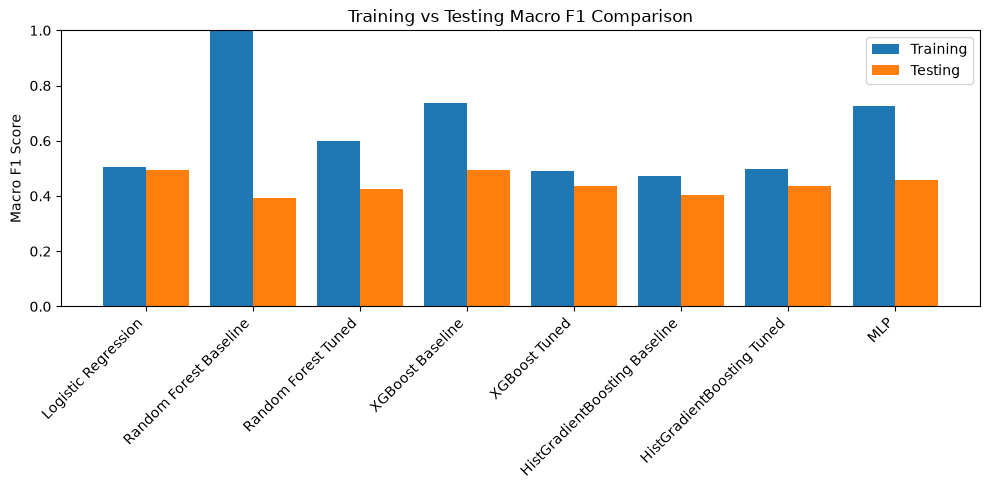

In [49]:
# Visualising the training vs the testing for each model
plt.figure(figsize=(10,5))

x = np.arange(len(overfitting_results["Model"]))

plt.bar(
    x - 0.2,
    overfitting_results["Training Macro F1"],
    width=0.4,
    label="Training"
)

plt.bar(
    x + 0.2,
    overfitting_results["Testing Macro F1"],
    width=0.4,
    label="Testing"
)

plt.xticks(
    x,
    overfitting_results["Model"],
    rotation=45,
    ha="right"
)

plt.ylabel("Macro F1 Score")
plt.title("Training vs Testing Macro F1 Comparison")
plt.legend()
plt.ylim(0,1)

plt.tight_layout()

plt.savefig(
    "figs/training_vs_testing_comparison.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

In [50]:
# Comparison table for all models
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression (Baseline)",
        "Random Forest (Baseline)",
        "Random Forest (Tuned)",
        "XGBoost (Baseline)",
        "XGBoost (Tuned)",
        "HistGradientBoosting (Baseline)",
        "HistGradientBoosting (Tuned)",
        "MLP"
    ],
    "Macro F1": [
        baseline_f1,
        rf_macro_f1,
        rf_tuned_f1,
        xgb_macro_f1,
        xgb_tuned_f1,
        hgb_f1,
        hgb_tuned_f1,
        mlp_f1
    ]
})

model_results = model_results.sort_values(
    by="Macro F1",
    ascending=False
)

model_results.round(3)

,Model,Macro F1
3,XGBoost (Baseline),0.493
0,Logistic Regression (Baseline),0.492
7,MLP,0.457
6,HistGradientBoosting (Tuned),0.436
4,XGBoost (Tuned),0.435
2,Random Forest (Tuned),0.425
5,HistGradientBoosting (Baseline),0.404
1,Random Forest (Baseline),0.392


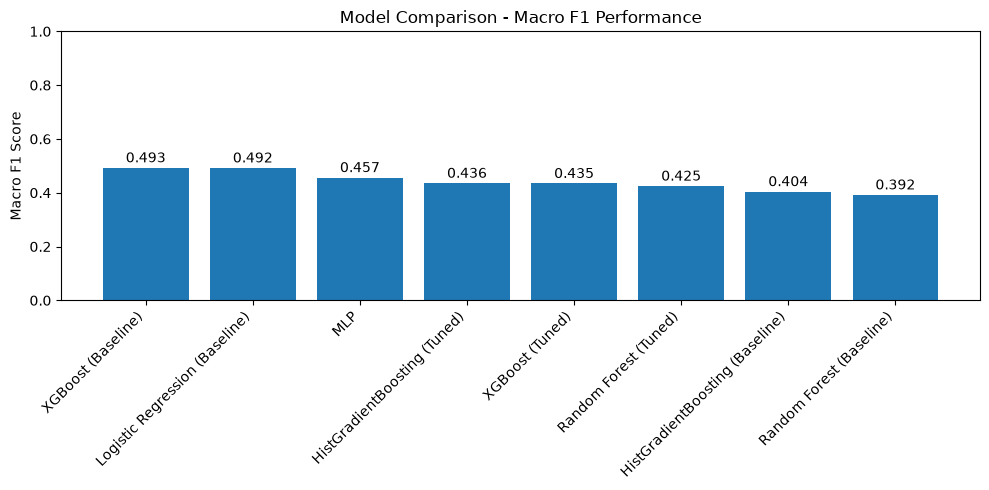

In [51]:
# visualise model performance

plt.figure(figsize=(10,5))

plt.bar(
    model_results["Model"],
    model_results["Macro F1"]
)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Macro F1 Score")
plt.title("Model Comparison - Macro F1 Performance")
plt.ylim(0,1)

for i, score in enumerate(model_results["Macro F1"]):
    plt.text(
        i,
        score + 0.02,
        f"{score:.3f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "figs/model_macro_f1_comparison.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

In [52]:
# saving final models
joblib.dump(best_rf, "w7_random_forest_tuned.joblib")
joblib.dump(best_xgb, "w7_xgboost_tuned.joblib")
joblib.dump(best_hgb, "w7_histgradientboosting_tuned.joblib")
joblib.dump(mlp, "w7_mlp.joblib")

print("All tuned models saved successfully.")

All tuned models saved successfully.


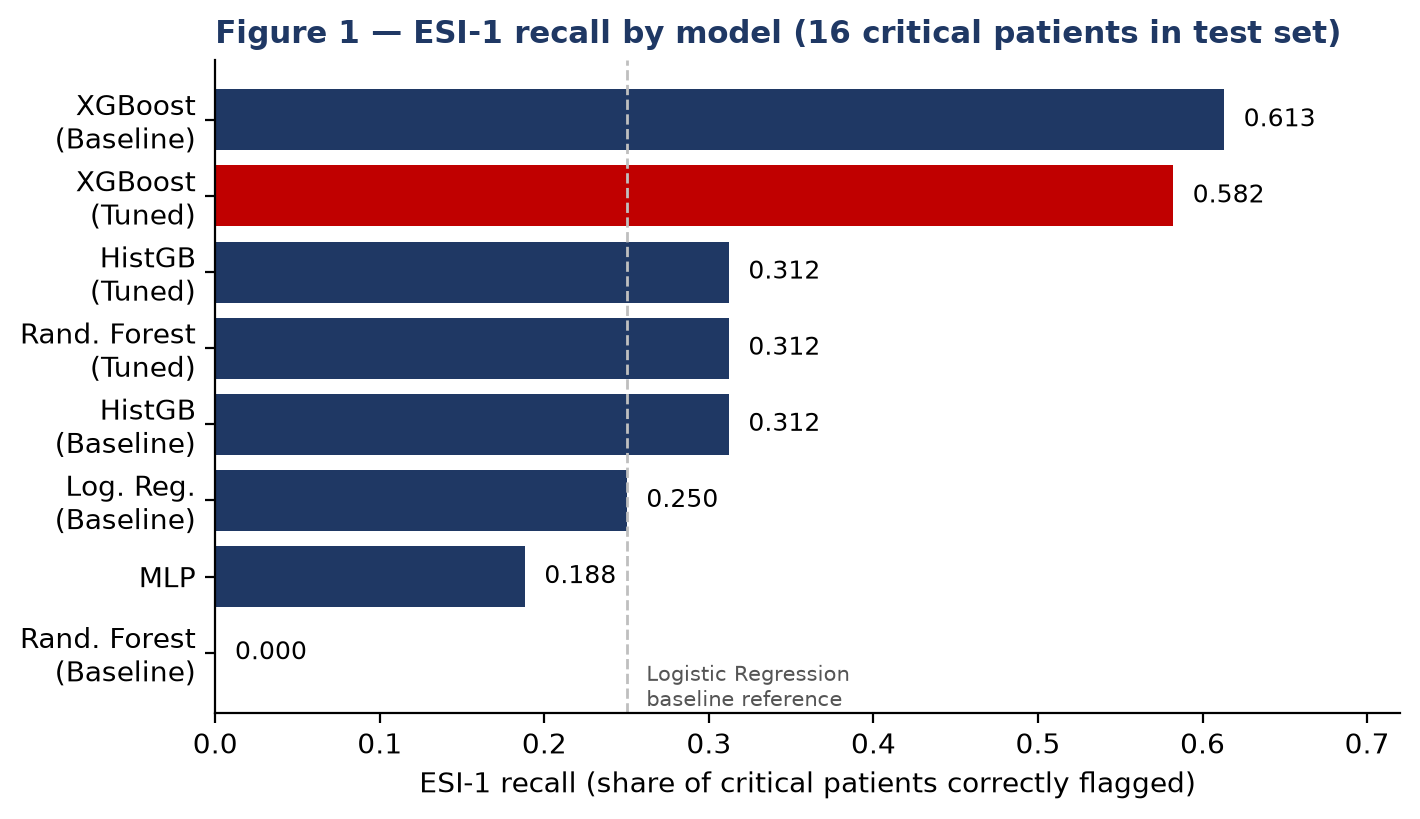

In [54]:
# esi recall visualisation
NAVY = "#1F3864"
HIGHLIGHT = "#C00000"
GREY = "#BFBFBF"

models = [
    "Logistic Regression (Baseline)",
    "XGBoost (Tuned)",
    "XGBoost (Baseline)",
    "MLP (Neural Network)",
    "HistGradientBoosting (Tuned)",
    "Random Forest (Tuned)",
    "HistGradientBoosting (Baseline)",
    "Random Forest (Baseline)",
]
esi1_recall = [0.250, 0.582, 0.613, 0.188, 0.312, 0.312, 0.312, 0.000]

short_labels = [
    "Log. Reg.\n(Baseline)",
    "XGBoost\n(Tuned)",
    "XGBoost\n(Baseline)",
    "MLP",
    "HistGB\n(Tuned)",
    "Rand. Forest\n(Tuned)",
    "HistGB\n(Baseline)",
    "Rand. Forest\n(Baseline)",
]

# Sort descending by ESI-1 recall
order = sorted(range(len(models)), key=lambda i: esi1_recall[i], reverse=True)
sorted_labels = [short_labels[i] for i in order]
sorted_recall = [esi1_recall[i] for i in order]
colors = [HIGHLIGHT if models[i] == "XGBoost (Tuned)" else NAVY for i in order]

fig, ax = plt.subplots(figsize=(7.2, 4.2), dpi=200)
bars = ax.barh(sorted_labels, sorted_recall, color=colors)
ax.invert_yaxis()  # highest value at the top
ax.set_xlabel("ESI-1 recall (share of critical patients correctly flagged)")
ax.set_xlim(0, 0.72)
ax.set_title("Figure 1 — ESI-1 recall by model (16 critical patients in test set)",
             fontsize=11, color=NAVY, weight="bold", loc="left")

# Value labels at the end of each bar
for bar, val in zip(bars, sorted_recall):
    ax.text(val + 0.012, bar.get_y() + bar.get_height() / 2, f"{val:.3f}",
            va="center", fontsize=9)

# Dashed reference line at the Logistic Regression baseline
ax.spines[["top", "right"]].set_visible(False)
ax.axvline(esi1_recall[0], color=GREY, linestyle="--", linewidth=1)
ax.text(esi1_recall[0] + 0.012, len(sorted_labels) - 0.3,
        "Logistic Regression\nbaseline reference", fontsize=7.5, color="#555555")

plt.tight_layout()
plt.savefig("figs/fig1_esi1_recall.png", bbox_inches="tight")
plt.show()